In [1]:
import matplotlib.pyplot as plt

In [2]:
# Path to your log file
log_path = "north_test.txt"

# Initialize dictionary
evals_result = {"train": {}, "validation": {}}

# Read file line by line
with open(log_path, "r") as f:
    for line in f:
        # Remove whitespace and split by tabs
        parts = line.strip().split("\t")
        if not parts or len(parts) < 2:
            continue

        # Loop through each metric part (skip first index part like [0])
        for p in parts[1:]:
            # Each metric looks like: train-logloss:0.68337
            try:
                key, val = p.split(":")
                val = float(val)
            except ValueError:
                continue  # skip malformed lines

            # Split into phase and metric, e.g. train-logloss → ("train", "logloss")
            phase, metric = key.split("-")

            # Initialize if needed
            if metric not in evals_result[phase]:
                evals_result[phase][metric] = []

            # Append value
            evals_result[phase][metric].append(val)

# Example usage:
print(evals_result["train"]["logloss"][:5])       # first 5 train logloss values
print(evals_result["validation"]["auc"][:5])      # first 5 validation auc values

[0.17771, 0.17586, 0.17405, 0.17226, 0.17048]
[0.99483, 0.99507, 0.99525, 0.99544, 0.99565]


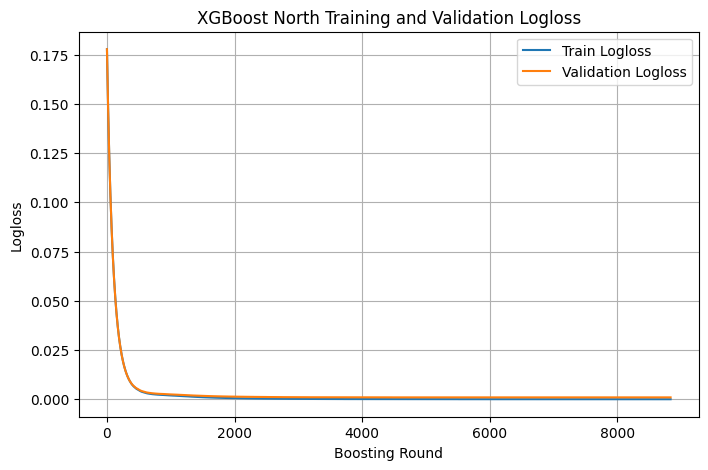

In [3]:
train_logloss = evals_result["train"]["logloss"]
valid_logloss = evals_result["validation"]["logloss"]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_logloss) + 1), train_logloss, label="Train Logloss")
plt.plot(range(1, len(valid_logloss) + 1), valid_logloss, label="Validation Logloss")
plt.xlabel("Boosting Round")
plt.ylabel("Logloss")
plt.title("XGBoost North Training and Validation Logloss")
plt.legend()
plt.grid(True)
plt.savefig('/home/users/clelland/Model/rerun/plots/north_learning_logloss.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

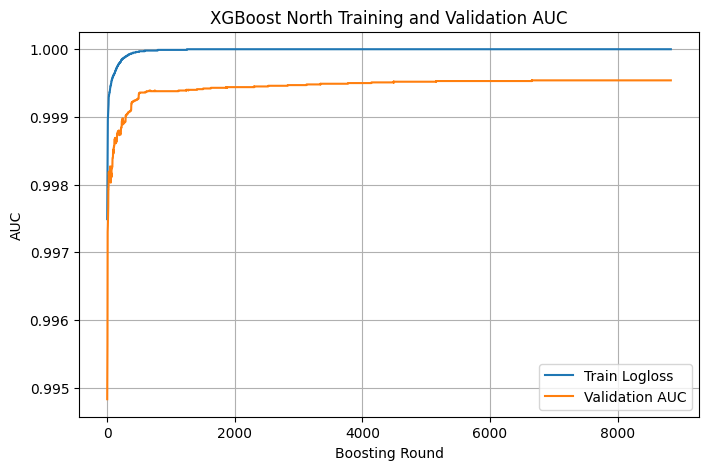

In [4]:
train_logloss = evals_result["train"]["auc"]
valid_auc = evals_result["validation"]["auc"]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_logloss) + 1), train_logloss, label="Train Logloss")
plt.plot(range(1, len(valid_auc) + 1), valid_auc, label="Validation AUC")
plt.xlabel("Boosting Round")
plt.ylabel("AUC")
plt.title("XGBoost North Training and Validation AUC")
plt.legend()
plt.grid(True)
plt.savefig('/home/users/clelland/Model/rerun/plots/north_learning_auc.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

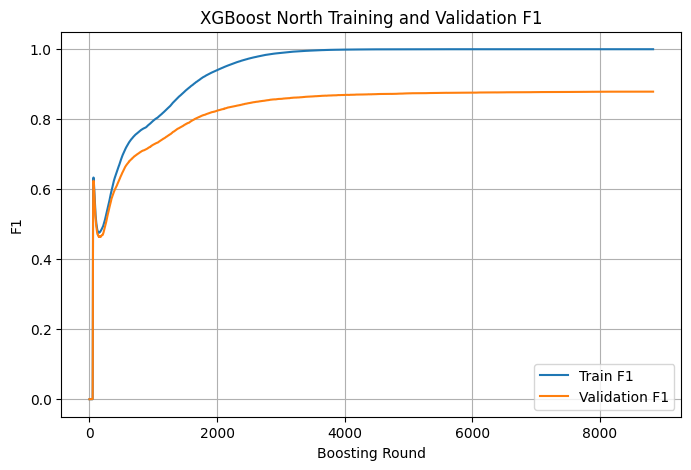

In [5]:
train_f1 = evals_result["train"]["f1"]
valid_f1 = evals_result["validation"]["f1"]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_f1) + 1), train_f1, label="Train F1")
plt.plot(range(1, len(valid_f1) + 1), valid_f1, label="Validation F1")
plt.xlabel("Boosting Round")
plt.ylabel("F1")
plt.title("XGBoost North Training and Validation F1")
plt.legend()
plt.grid(True)
plt.savefig('/home/users/clelland/Model/rerun/plots/north_learning_f1.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

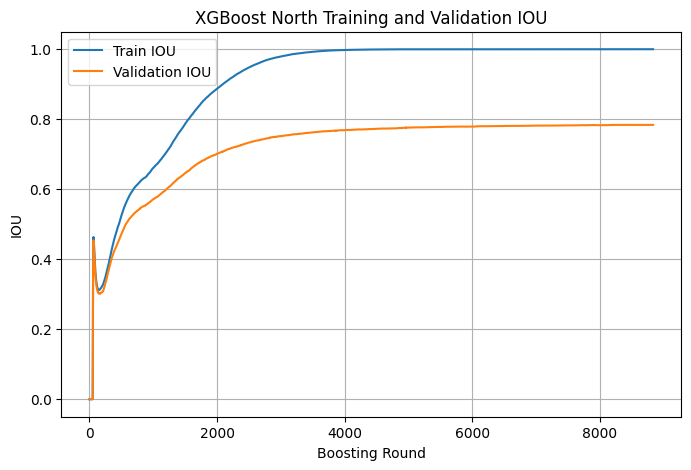

In [6]:
train_iou = evals_result["train"]["iou"]
valid_iou = evals_result["validation"]["iou"]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_iou) + 1), train_iou, label="Train IOU")
plt.plot(range(1, len(valid_iou) + 1), valid_iou, label="Validation IOU")
plt.xlabel("Boosting Round")
plt.ylabel("IOU")
plt.title("XGBoost North Training and Validation IOU")
plt.legend()
plt.grid(True)
plt.savefig('/home/users/clelland/Model/rerun/plots/north_learning_iou.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()